# 03 - CICIDS2017: Multi-Class Machine Learning Benchmark (Subset Dataset)

## Objective
Evaluate the top 3 state-of-the-art tree-based Machine Learning models on the clean, balanced CICIDS2017 subset (`CICIDS_clean_subset.parquet`):
- **169,686 rows**, 44 clean features, 7 classes.
- Balanced ~59% Benign : 41% Attacks ratio.

### Models Evaluated:
1. **Random Forest (Balanced)** — Bagged decision trees with `balanced_subsample` weights
2. **LightGBM (Balanced)** — Gradient boosted trees with `is_unbalance=True`
3. **XGBoost (Balanced)** — Histogram-based extreme gradient boosting with balanced sample weights

### Evaluation Metrics:
- **Accuracy** (Unseen test set performance)
- **Weighted F1** (Aggregate multi-class F1 score)
- **Macro F1** (Unweighted mean across all 7 classes, evaluating rare attacks fairly)
- **Train Time (s)** (Computational efficiency)

In [4]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Load Clean Subset Dataset & Preprocess (Fast Parquet Loading)

In [5]:
t0 = time.time()
df = pd.read_parquet('../Datasets/CICIDS_clean_subset.parquet')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns in {time.time()-t0:.2f} seconds!")

X = df.drop(columns=['Label'])
y = df['Label']

# Encode Target Labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)
classes = list(label_encoder.classes_)
num_classes = len(classes)
print(f"Target classes ({num_classes}): {classes}")

# Stratified Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=SEED
)

# Standard Scaling with clipping to [-10, 10]
scaler = StandardScaler()
X_train_scaled = np.clip(scaler.fit_transform(X_train), -10, 10)
X_test_scaled = np.clip(scaler.transform(X_test), -10, 10)

# Compute balanced sample weights for XGBoost
sample_weights_train = compute_sample_weight('balanced', y_train)

print(f"Train Shape: {X_train_scaled.shape} | Test Shape: {X_test_scaled.shape}")
print("Preprocessing complete!")

Loaded 169,686 rows and 45 columns in 0.07 seconds!
Target classes (7): ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack']
Train Shape: (135748, 44) | Test Shape: (33938, 44)
Preprocessing complete!


## 2. Model Training & Benchmarking (Random Forest, LightGBM, XGBoost)

We train all three tree-based gradient boosted & ensemble algorithms under identical train/test splits with balanced class weighting.

In [6]:
models = {
    "Random Forest (Balanced)": RandomForestClassifier(
        n_estimators=100,
        max_depth=16,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1
    ),
    "LightGBM (Balanced)": LGBMClassifier(
        n_estimators=150,
        max_depth=8,
        learning_rate=0.05,
        is_unbalance=True,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ),
    "XGBoost (Balanced)": xgb.XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.08,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
}

benchmark_results = []
fitted_models = {}

for name, model in models.items():
    print(f"--> Training {name}...")
    start_train = time.time()
    
    if name == "XGBoost (Balanced)":
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_scaled, y_train)
        
    train_time = time.time() - start_train
    fitted_models[name] = model
    
    # Evaluate on test set
    test_preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, test_preds)
    prec = precision_score(y_test, test_preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, test_preds, average='weighted', zero_division=0)
    w_f1 = f1_score(y_test, test_preds, average='weighted', zero_division=0)
    m_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    
    benchmark_results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted F1": w_f1,
        "Macro F1": m_f1,
        "Train Time (s)": train_time
    })
    print(f"    Accuracy: {acc:.4f} | Weighted F1: {w_f1:.4f} | Macro F1: {m_f1:.4f} | Time: {train_time:.2f}s")


print("\nAll models trained and evaluated successfully!")


--> Training Random Forest (Balanced)...
    Accuracy: 0.9922 | Weighted F1: 0.9926 | Macro F1: 0.9579 | Time: 5.02s
--> Training LightGBM (Balanced)...
    Accuracy: 0.9987 | Weighted F1: 0.9987 | Macro F1: 0.9931 | Time: 5.53s
--> Training XGBoost (Balanced)...
    Accuracy: 0.9980 | Weighted F1: 0.9980 | Macro F1: 0.9887 | Time: 9.11s

All models trained and evaluated successfully!


## 3. Comparison Matrix & Performance Visualization

,Model,Accuracy,Weighted F1,Macro F1,Train Time (s)
0,Random Forest (Balanced),0.992162,0.992643,0.957925,5.019167
1,LightGBM (Balanced),0.998733,0.998732,0.993097,5.529997
2,XGBoost (Balanced),0.998026,0.998043,0.988652,9.114596


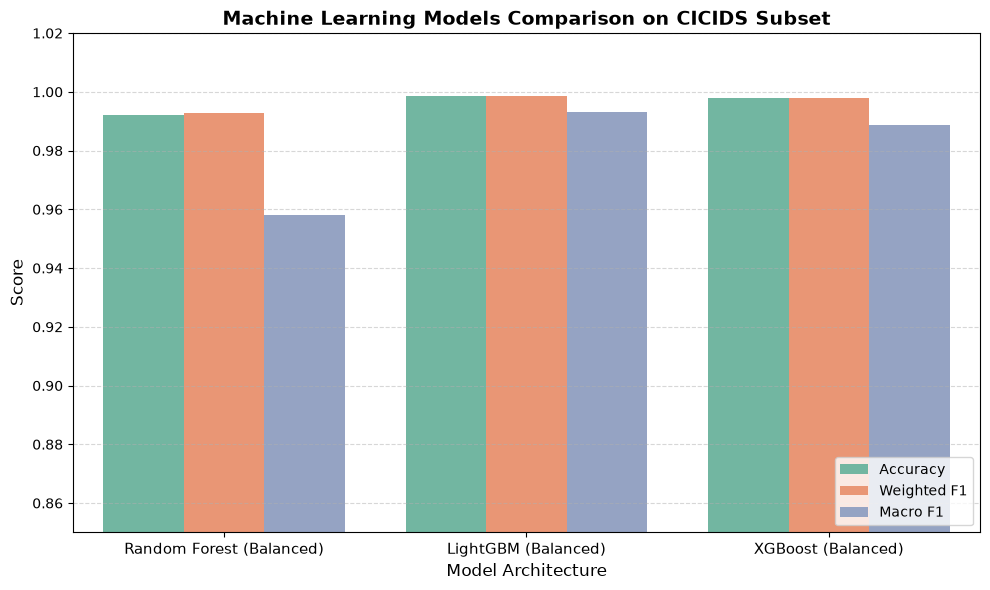

In [7]:
comparison_df = pd.DataFrame(benchmark_results)
display(comparison_df.style.highlight_max(subset=["Accuracy", "Weighted F1", "Macro F1"], color="lightgreen")
                           .highlight_min(subset=["Train Time (s)"], color="lightblue"))

# Visual Comparison of Accuracy, Weighted F1, and Macro F1
plt.figure(figsize=(10, 6))
melted = comparison_df.melt(id_vars=["Model"], value_vars=["Accuracy", "Weighted F1", "Macro F1"], var_name="Metric", value_name="Score")
sns.barplot(data=melted, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Machine Learning Models Comparison on CICIDS Subset", fontsize=14, fontweight="bold")
plt.ylim(0.85, 1.02)
plt.xticks(fontsize=11)
plt.xlabel("Model Architecture", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(loc="lower right", frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Detailed Per-Class Classification Report & Confusion Matrix (Best Model)

=== Best Model Overall (by Macro F1): LightGBM (Balanced) ===

Detailed Per-Class Performance Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     20001
         Bot       0.98      0.99      0.98       287
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00      5000
         DoS       1.00      1.00      1.00      6000
    PortScan       0.99      0.97      0.98       391
  Web Attack       1.00      0.98      0.99       429

    accuracy                           1.00     33938
   macro avg       0.99      0.99      0.99     33938
weighted avg       1.00      1.00      1.00     33938



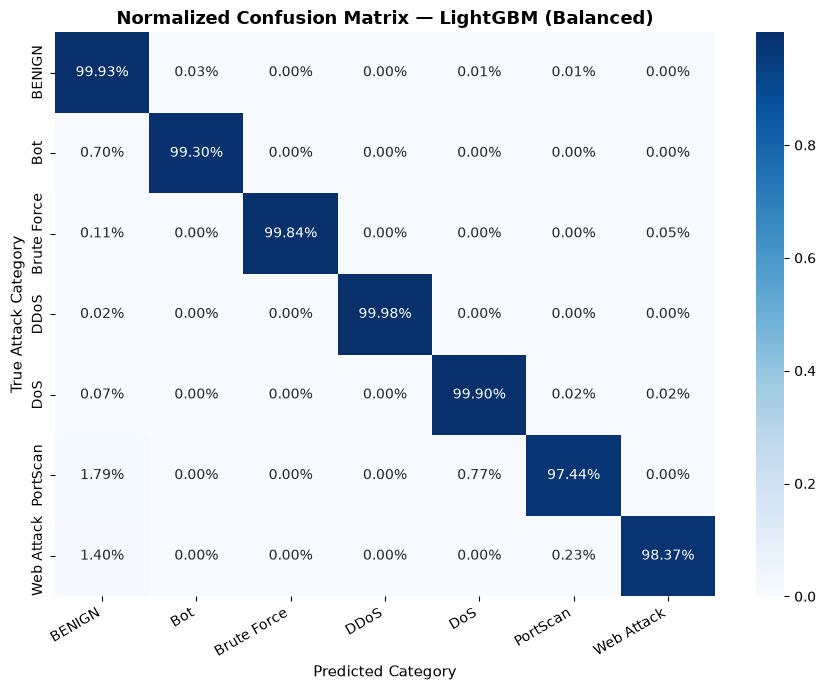

In [8]:
best_idx = comparison_df["Macro F1"].idxmax()
best_name = comparison_df.loc[best_idx, "Model"]
print(f"=== Best Model Overall (by Macro F1): {best_name} ===")

best_model = fitted_models[best_name]
final_preds = best_model.predict(X_test_scaled)

print("\nDetailed Per-Class Performance Report:")
print(classification_report(y_test, final_preds, target_names=classes, zero_division=0))

# Normalized Confusion Matrix Heatmap
cm = confusion_matrix(y_test, final_preds, normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title(f"Normalized Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
plt.ylabel("True Attack Category", fontsize=11)
plt.xlabel("Predicted Category", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Save Artifacts to Models Directory

In [ ]:
import joblib

os.makedirs("../Models", exist_ok=True)
joblib.dump(scaler, "../Models/subset_ml_scaler.pkl")
joblib.dump(label_encoder, "../Models/subset_ml_label_encoder.pkl")
comparison_df.to_csv("../Models/subset_ml_comparison_benchmark.csv", index=False)
joblib.dump(fitted_models["Random Forest (Balanced)"], "../Models/random_forest_balanced.pkl")
joblib.dump(fitted_models["LightGBM (Balanced)"], "../Models/lightgbm_balanced.pkl")
joblib.dump(fitted_models["XGBoost (Balanced)"], "../Models/xgboost_balanced.pkl")

print("Successfully saved all trained ML models, preprocessors, and comparison benchmark to ../Models/!")